In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy import nan as NA
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv('Titanic-Dataset.csv')   #choose the correct path for yourself
titanic = df.head(21)
titanic.to_csv('Titanic_sample.csv')    #choose the correct path for yourself
print()
#DESCRIBE + MISSING DATA
describe =df.describe().round(2)
print("describe = \n",describe)
describe.to_csv('describe.csv')   #choose the correct path for yourself



describe = 
        PassengerId  Survived  Pclass     Age   SibSp   Parch    Fare
count       891.00    891.00  891.00  714.00  891.00  891.00  891.00
mean        446.00      0.38    2.31   29.70    0.52    0.38   32.20
std         257.35      0.49    0.84   14.53    1.10    0.81   49.69
min           1.00      0.00    1.00    0.42    0.00    0.00    0.00
25%         223.50      0.00    2.00   20.12    0.00    0.00    7.91
50%         446.00      0.00    3.00   28.00    0.00    0.00   14.45
75%         668.50      1.00    3.00   38.00    1.00    0.00   31.00
max         891.00      1.00    3.00   80.00    8.00    6.00  512.33


In [23]:
df["Sex"] = df["Sex"].map({"male" : 0 , "female" : 1})   #changing to int
features = ['Sex','Pclass','Fare','SibSp','Parch']   #selecting the right columns
df_full = df[df["Age"].notnull()]
df_missing = df[df["Age"].isnull()]

training model and finding the missing values with it

In [24]:
x_train = df_full[features]
y_train = df_full["Age"]
model = RandomForestRegressor()
model.fit(x_train,y_train)
x_missing = df_missing[features]
predicted_ages = model.predict(x_missing)
df.loc[df["Age"].isnull(),"Age"] = predicted_ages


Function to detect outliers

In [25]:
def detect_outliers(a):
    Q1 = a.quantile(0.25)
    Q3 = a.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (a<lower_bound)|(a>upper_bound)

detecting outliers and removing them

In [28]:
outliers_age=detect_outliers(df["Age"])
print("total of age values: \n",len(df["Age"]))   
print("number of outliers in age :\n",outliers_age.sum()) 
print("percentage of outliers in age:\n",(outliers_age.sum())/len(df["Age"])*100)
print("outlier values :\n",df["Age"][outliers_age].tolist())
df = df[~outliers_age]
df = df.reset_index(drop=True)

total of age values: 
 861
number of outliers in age :
 0
percentage of outliers in age:
 0.0
outlier values :
 []


% OF PPL THAT SURVIVED

In [29]:
female_survive = len (df[(df['Sex'] == 1) & (df['Survived'] == 1)])
print('number of female that survived = \n',female_survive)
print()
male_survive = len (df[(df['Sex'] == 0)&(df['Survived'] == 1)])
print('number of men that survived = \n',male_survive)
print()
len_female = len(df[df['Sex'] == 1])
len_male = len(df[df['Sex'] == 0])
print(len_female)
print()
print(len_male)
percent_survive_female = (female_survive/len_female) * 100
percent_survive_male = (male_survive/len_male) * 100
print()
print('% of female that survived = \n',percent_survive_female)
print()
print('% of male that survived = \n', percent_survive_male)
print()

number of female that survived = 
 229

number of men that survived = 
 106

310

551

% of female that survived = 
 73.87096774193549

% of male that survived = 
 19.237749546279492



Survival Rate by Passenger Class — Grouped Percentage Calculation

In [30]:
percent_survive_class = df.groupby('Pclass')['Survived'].mean() * 100
print('% of survived from each class:\n', percent_survive_class)

% of survived from each class:
 Pclass
1    66.497462
2    48.044693
3    24.329897
Name: Survived, dtype: float64


Survival Rate by Gender and Passenger Class — Grouped Analysis

In [31]:
percent_survive_class_gender = df.groupby(['Sex','Pclass'])['Survived'].mean() * 100
print('% of survived from each class and gender:\n', percent_survive_class_gender)

% of survived from each class and gender:
 Sex  Pclass
0    1         40.566038
     2         15.533981
     3         13.742690
1    1         96.703297
     2         92.105263
     3         49.650350
Name: Survived, dtype: float64


Average Age Comparison Between Survivors and Non‑Survivors

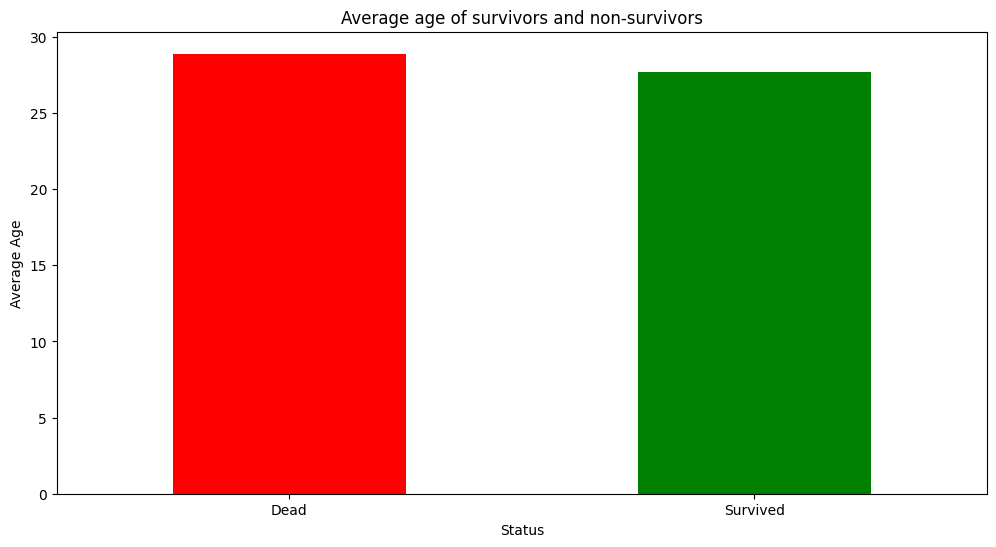

In [32]:
a = df.groupby('Survived')['Age'].mean()

a.index = ['Dead', 'Survived']

plt.figure(figsize=(12,6))
a.plot(kind='bar', rot=0, color=['red','green'])
plt.xlabel('Status')
plt.ylabel('Average Age')
plt.title('Average age of survivors and non-survivors')
plt.show()

Survival Rate by Age Groups — Binned Age Analysis

0      (17.694, 23.452]
1      (34.968, 40.726]
2       (23.452, 29.21]
3      (34.968, 40.726]
4      (34.968, 40.726]
             ...       
856     (23.452, 29.21]
857    (17.694, 23.452]
858    (11.936, 17.694]
859     (23.452, 29.21]
860     (29.21, 34.968]
Name: Age_Group, Length: 861, dtype: category
Categories (10, interval[float64, right]): [(0.362, 6.178] < (6.178, 11.936] < (11.936, 17.694] < (17.694, 23.452] ... (34.968, 40.726] < (40.726, 46.484] < (46.484, 52.242] < (52.242, 58.0]]



C:\Users\Sam-Tech\AppData\Local\Temp\ipykernel_15396\3529964243.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a = df.groupby('Age_Group')['Survived'].mean() * 100


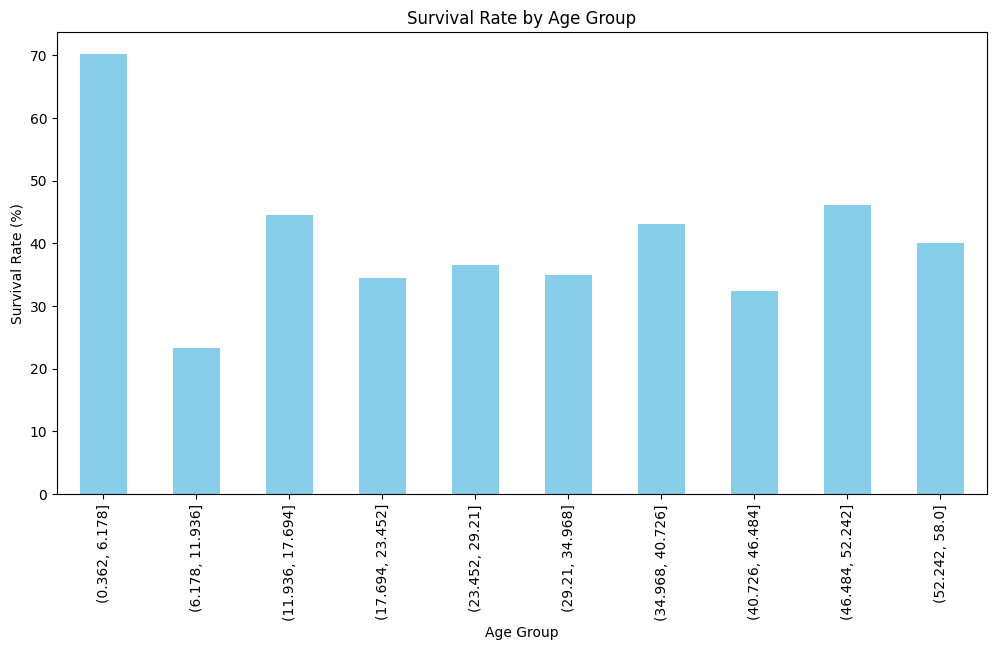

In [33]:
# گروه‌بندی سن‌ها به 10 بازه مساوی
df['Age_Group'] = pd.cut(df['Age'], 10)

print(df['Age_Group'])
print()

# محاسبه نرخ زنده‌ماندن برای هر گروه سنی
a = df.groupby('Age_Group')['Survived'].mean() * 100

plt.figure(figsize=(12,6))
a.plot(kind='bar', rot=90, color='skyblue')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate (%)')
plt.title('Survival Rate by Age Group')
plt.show()

Survival Rate by Age Group and Gender — Multi‑Index Analysis

In [34]:
# گروه‌بندی سن‌ها به 10 بازه مساوی
df['Age_Group'] = pd.cut(df['Age'], 10)

# محاسبه نرخ زنده‌ماندن بر اساس گروه سنی و جنسیت
a = df.groupby(['Age_Group', 'Sex'])['Survived'].mean().unstack() * 100

print(a.head(10))

Sex                       0          1
Age_Group                             
(0.362, 6.178]    66.666667  73.913043
(6.178, 11.936]   23.529412  23.076923
(11.936, 17.694]  13.043478  67.741935
(17.694, 23.452]  11.111111  68.852459
(23.452, 29.21]   17.164179  77.777778
(29.21, 34.968]   16.666667  84.210526
(34.968, 40.726]  17.460317  86.486486
(40.726, 46.484]  21.276596  61.111111
(46.484, 52.242]  30.555556  81.250000
(52.242, 58.0]     6.666667  90.000000


C:\Users\Sam-Tech\AppData\Local\Temp\ipykernel_15396\3850882937.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a = df.groupby(['Age_Group', 'Sex'])['Survived'].mean().unstack() * 100
